# Processed demo IRI-seq pipeline

Adapted for the GSE270383 mouse hippocampus demo processed supplementary files instead of raw FASTQ files.

- Processed input directory: `/p2/zulab/jtian/data/IRISeq/demo_processed/`
- Output directory: `/p2/zulab/jtian/data/IRISeq/demo_processed/`
- Required processed cDNA files:
  - `GSM8341603_barcodes_Hip_demo.tsv.gz`
  - `GSM8341603_count_Hip_demo.mtx.gz`
  - `GSM8341603_genes_Hip_demo.tsv.gz`
  - `GSM8341603_metadata_Hip_demo.csv.gz`
- The raw FASTQ alignment/counting steps are skipped; this notebook starts from the processed count matrix and metadata.
- Optional spatial interaction input, only for the final interaction UMAP section: `beads_UMI8/Spatial_barcode_rmdup/GSM8341604_interaction.spatial.csv.gz` under the same processed directory.


In [1]:
from pathlib import Path
import gzip
import hashlib
import os
import re
import shutil
import subprocess
import sys
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import io, sparse
import matplotlib.pyplot as plt
import umap
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
PROJECT_DIR = Path('/p1/zulab_users/jtian/my_jupyter/IRI-seq')
DEMO_DIR = Path('/p2/zulab/jtian/data/IRISeq/demo_processed')
RAW_DATA_DIR = DEMO_DIR/'Data'
OUTPUT_DIR = DEMO_DIR/'output'

CDNA_OUTPUT = OUTPUT_DIR / 'cDNA'
BEAD_OUTPUT_UMI8 = OUTPUT_DIR / 'beads_UMI8'
CONNECTION_OUTPUT = OUTPUT_DIR / 'connections'
UMAP_OUTPUT = CONNECTION_OUTPUT / 'UMAP'

CDNA_SAMPLES = ['GSM8341603_cDNA']
BEAD_SAMPLES = ['GSM8341604_interaction']

PROCESSED_FILES = {
    'barcodes': RAW_DATA_DIR / 'GSM8341603_barcodes_Hip_demo.tsv.gz',
    'count': RAW_DATA_DIR / 'GSM8341603_count_Hip_demo.mtx.gz',
    'genes': RAW_DATA_DIR / 'GSM8341603_genes_Hip_demo.tsv.gz',
    'metadata': RAW_DATA_DIR / 'GSM8341603_metadata_Hip_demo.csv.gz',
}

ADATA_FOLDER = CDNA_OUTPUT / 'Adata'
FIGURE_DIR = CDNA_OUTPUT / 'figures'
DEDUPLICATE_SPATIAL_UMI8 = BEAD_OUTPUT_UMI8 / 'Spatial_barcode_rmdup'

for path in [OUTPUT_DIR, CDNA_OUTPUT, ADATA_FOLDER, FIGURE_DIR, BEAD_OUTPUT_UMI8, DEDUPLICATE_SPATIAL_UMI8, CONNECTION_OUTPUT, UMAP_OUTPUT]:
    path.mkdir(parents=True, exist_ok=True)

print('RAW_DATA_DIR =', RAW_DATA_DIR)
print('OUTPUT_DIR   =', OUTPUT_DIR)
print('CDNA_SAMPLES =', CDNA_SAMPLES)
print('BEAD_SAMPLES =', BEAD_SAMPLES)


RAW_DATA_DIR = /p2/zulab/jtian/data/IRISeq/demo_processed/Data
OUTPUT_DIR   = /p2/zulab/jtian/data/IRISeq/demo_processed/output
CDNA_SAMPLES = ['GSM8341603_cDNA']
BEAD_SAMPLES = ['GSM8341604_interaction']


## Processed input files

Download the four processed cDNA supplementary files into `RAW_DATA_DIR`. The matrix is loaded directly into AnnData, so FASTQ demultiplexing, trimming, STAR alignment, SAM filtering, duplicate removal, gene counting, and raw read-count reporting are skipped.


In [3]:
processed_file_rows = []
for key, path in PROCESSED_FILES.items():
    processed_file_rows.append({
        'role': key,
        'path': str(path),
        'exists': path.exists(),
        'size_MB': round(path.stat().st_size / 1024**2, 3) if path.exists() else None,
    })
processed_file_table = pd.DataFrame(processed_file_rows)
display(processed_file_table)
assert processed_file_table['exists'].all(), 'Missing one or more processed input files in RAW_DATA_DIR.'


,role,path,exists,size_MB
0,barcodes,/p2/zulab/jtian/data/IRISeq/demo_processed/Dat...,True,0.111
1,count,/p2/zulab/jtian/data/IRISeq/demo_processed/Dat...,True,56.880
2,genes,/p2/zulab/jtian/data/IRISeq/demo_processed/Dat...,True,0.090
3,metadata,/p2/zulab/jtian/data/IRISeq/demo_processed/Dat...,True,0.504


In [4]:
barcodes = pd.read_csv(PROCESSED_FILES['barcodes'], sep='	', header=None, compression='infer')
genes = pd.read_csv(PROCESSED_FILES['genes'], sep='	', header=None, compression='infer')
metadata_raw = pd.read_csv(PROCESSED_FILES['metadata'], compression='infer')
count_matrix = io.mmread(PROCESSED_FILES['count'])
if not sparse.issparse(count_matrix):
    count_matrix = sparse.csr_matrix(count_matrix)
else:
    count_matrix = count_matrix.tocsr()

barcode_names = barcodes.iloc[:, 0].astype(str).tolist()
gene_ids = genes.iloc[:, 0].astype(str).tolist()
gene_names = genes.iloc[:, 1].astype(str).tolist() if genes.shape[1] > 1 else gene_ids

if count_matrix.shape == (len(gene_ids), len(barcode_names)):
    X = count_matrix.T.tocsr()
elif count_matrix.shape == (len(barcode_names), len(gene_ids)):
    X = count_matrix.tocsr()
else:
    raise ValueError(
        f'Count matrix shape {count_matrix.shape} does not match '
        f'{len(barcode_names)} barcodes and {len(gene_ids)} genes.'
    )

obs = pd.DataFrame(index=pd.Index(barcode_names, name='barcode'))
metadata = metadata_raw.copy()
metadata_indexed = False
for candidate in [metadata.columns[0], 'barcode', 'Barcode', 'cell', 'cell_id', 'CellID', 'cell_name']:
    if candidate in metadata.columns:
        candidate_values = metadata[candidate].astype(str)
        overlap = len(set(candidate_values) & set(obs.index.astype(str)))
        if overlap:
            metadata = metadata.set_index(candidate)
            metadata_indexed = True
            break
if not metadata_indexed:
    metadata = metadata_raw.copy()
    metadata.index = metadata.index.astype(str)

obs = obs.join(metadata, how='left')
obs['sample_source'] = CDNA_SAMPLES[0]
obs['extracted_ID'] = obs.index.to_series().astype(str).str.split('.').str[-1].str.replace('-', '', regex=False)
obs['source_matrix'] = PROCESSED_FILES['count'].name

var = pd.DataFrame(index=pd.Index(gene_ids, name='gene_id'))
var['Gene_name'] = gene_names
var['gene_id'] = gene_ids

adata = sc.AnnData(X=X, obs=obs, var=var)
adata.var_names_make_unique()
adata.write_h5ad(ADATA_FOLDER / 'adata_full.h5ad')

print('Saved', ADATA_FOLDER / 'adata_full.h5ad')
print(adata)
display(adata.obs.head())
display(adata.var.head())


Saved /p2/zulab/jtian/data/IRISeq/demo_processed/output/cDNA/Adata/adata_full.h5ad
AnnData object with n_obs × n_vars = 16940 × 26139
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'extracted_ID', 'UMAP1', 'UMAP2', 'sample_source', 'source_matrix'
    var: 'Gene_name', 'gene_id'


,orig.ident,nCount_RNA,nFeature_RNA,extracted_ID,UMAP1,UMAP2,sample_source,source_matrix
barcode,,,,,,,,
20240522_Min20_cDNA.ACACCGTA-AACAACCG-CTCACAGT-TCGTGCAA,20240522,120,107,ACACCGTAAACAACCGCTCACAGTTCGTGCAA,4.749886,0.669519,GSM8341603_cDNA,GSM8341603_count_Hip_demo.mtx.gz
20240522_Min20_cDNA.ACACCGTA-AACACGAC-ACACTCAG-AGTGCGAT,20240522,197,178,ACACCGTAAACACGACACACTCAGAGTGCGAT,-11.071051,-2.363361,GSM8341603_cDNA,GSM8341603_count_Hip_demo.mtx.gz
20240522_Min20_cDNA.ACACCGTA-AACACGAC-CAAGGTGA-TCACGGAT,20240522,10152,4357,ACACCGTAAACACGACCAAGGTGATCACGGAT,-5.411638,7.153830,GSM8341603_cDNA,GSM8341603_count_Hip_demo.mtx.gz
20240522_Min20_cDNA.ACACCGTA-AACACGAC-GGCTCAAT-ACGCTCTA,20240522,62,60,ACACCGTAAACACGACGGCTCAATACGCTCTA,4.616203,8.437395,GSM8341603_cDNA,GSM8341603_count_Hip_demo.mtx.gz
20240522_Min20_cDNA.ACACCGTA-AACCAGGT-AGCACATG-CCTAACGC,20240522,386,316,ACACCGTAAACCAGGTAGCACATGCCTAACGC,8.752335,6.525337,GSM8341603_cDNA,GSM8341603_count_Hip_demo.mtx.gz


,Gene_name,gene_id
gene_id,,
Gnai3,Gnai3,Gnai3
Pbsn,Pbsn,Pbsn
Cdc45,Cdc45,Cdc45
H19,H19,H19
Scml2,Scml2,Scml2


## Scanpy cDNA analysis

This section is kept close to the original demo notebook, but it now starts from `adata_full.h5ad` created from the processed count matrix.


In [5]:
adata_path = CDNA_OUTPUT / 'Adata' / 'adata_full.h5ad'
assert adata_path.exists(), f'Missing AnnData file: {adata_path}'
adata = sc.read_h5ad(adata_path)

In [6]:
if 'sample_source' not in adata.obs.columns or adata.obs['sample_source'].isna().all():
    adata.obs['sample_source'] = CDNA_SAMPLES[0]
else:
    adata.obs['sample_source'] = adata.obs['sample_source'].fillna(CDNA_SAMPLES[0])

if 'extracted_ID' not in adata.obs.columns or adata.obs['extracted_ID'].isna().all():
    adata.obs['extracted_ID'] = (
        adata.obs.index.to_series().astype(str)
        .str.split('.')
        .str[-1]
        .str.replace('-', '', regex=False)
    )
else:
    adata.obs['extracted_ID'] = adata.obs['extracted_ID'].astype(str).str.replace('-', '', regex=False)

# Keep mouse genes only when Ensembl-style mouse IDs are present.
mouse_gene_mask = adata.var.index.astype(str).str.startswith('ENSMUSG')
if mouse_gene_mask.any():
    adata.var['Mouse_gene'] = mouse_gene_mask
    adata = adata[:, adata.var['Mouse_gene']].copy()

# Use gene symbols as var names when they are available from the processed gene table.
if 'Gene_name' in adata.var.columns:
    adata.var.index = adata.var['Gene_name'].astype(str)
    adata.var_names_make_unique()


In [7]:
adata.var['mt'] = adata.var_names.str.upper().str.startswith('MT-')
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt'],
    percent_top=None,
    log1p=False,
    inplace=True,
)

### Pre-filter cDNA QC violin plots without extreme values

These plots use the unfiltered `adata` object after QC metrics are calculated. Extreme values are removed from the plotting copy only.


,sample,n_barcodes_before_plot_trim,total_counts_plot_upper_q99,n_genes_by_counts_plot_upper_q99,pct_counts_mt_plot_upper_q99,n_barcodes_after_plot_trim,n_barcodes_removed_from_plot_only
0,GSM8341603_cDNA,16940,20985.59,6308.0,8.385788,16587,353


/p1/zulab_users/jtian/anaconda3/envs/my_IRISeq_py38/lib/python3.8/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/p1/zulab_users/jtian/anaconda3/envs/my_IRISeq_py38/lib/python3.8/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/p1/zulab_users/jtian/anaconda3/envs/my_IRISeq_py38/lib/python3.8/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/p1/zulab_users/jtian/anaconda3/envs/my_IRISeq_py38/lib/python3.8/site-packages/scanpy/pl

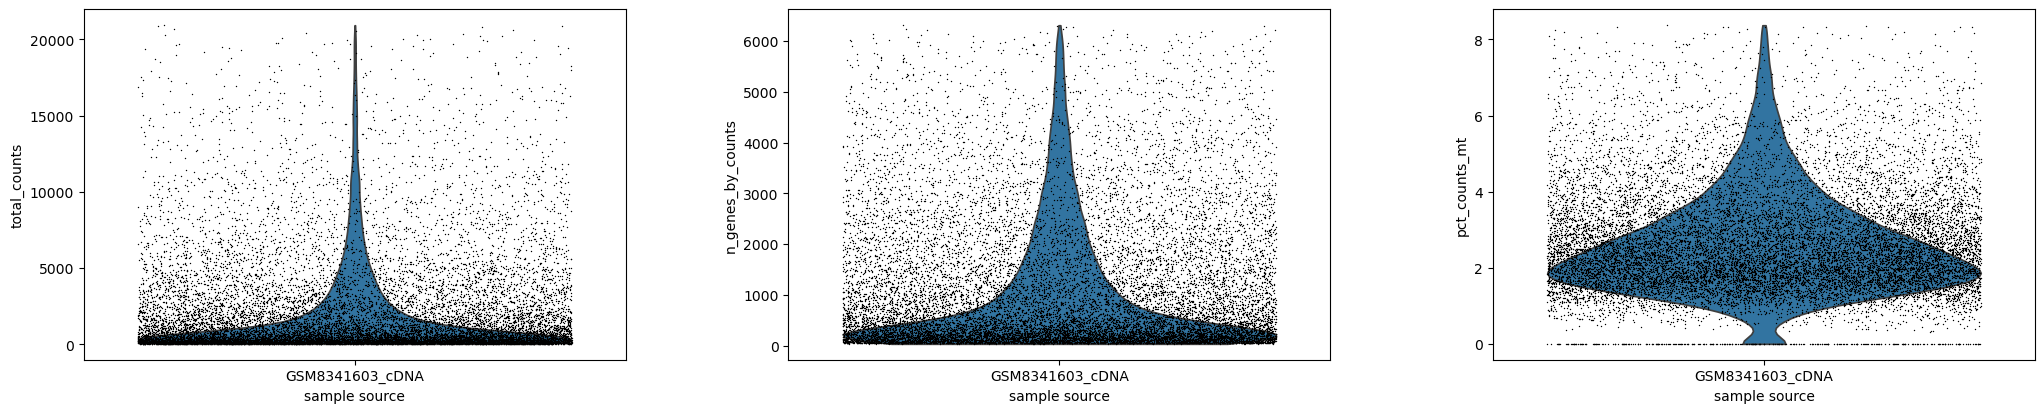

Saved /p2/zulab/jtian/data/IRISeq/demo_processed/output/cDNA/figures/cDNA_prefilter_QC_violin_without_extreme_values.png
Saved /p2/zulab/jtian/data/IRISeq/demo_processed/output/cDNA/Adata/cDNA_prefilter_violin_plot_trim_summary.csv
Note: extreme values were removed only from adata_violin_prefilter for plotting; adata was not modified.


In [8]:
fig_dir = CDNA_OUTPUT / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

violin_metrics = ['total_counts', 'n_genes_by_counts', 'pct_counts_mt']
violin_upper_quantile = {
    'total_counts': 0.99,
    'n_genes_by_counts': 0.99,
    'pct_counts_mt': 0.99,
}

plot_obs = adata.obs[['sample_source'] + violin_metrics].copy()
plot_obs = plot_obs.dropna(subset=['sample_source'])

trim_summary_rows = []
plot_masks = []
for sample in CDNA_SAMPLES:
    sample_mask = plot_obs['sample_source'] == sample
    if not sample_mask.any():
        continue
    keep_mask = sample_mask.copy()
    row = {'sample': sample, 'n_barcodes_before_plot_trim': int(sample_mask.sum())}
    for metric in violin_metrics:
        upper = plot_obs.loc[sample_mask, metric].quantile(violin_upper_quantile[metric])
        row[f'{metric}_plot_upper_q99'] = upper
        keep_mask &= plot_obs[metric] <= upper
    row['n_barcodes_after_plot_trim'] = int(keep_mask.sum())
    row['n_barcodes_removed_from_plot_only'] = int(sample_mask.sum() - keep_mask.sum())
    trim_summary_rows.append(row)
    plot_masks.append(keep_mask)

if plot_masks:
    plot_keep = plot_masks[0].copy()
    for mask in plot_masks[1:]:
        plot_keep |= mask
else:
    plot_keep = pd.Series(False, index=plot_obs.index)

adata_violin_prefilter = adata[plot_keep.reindex(adata.obs.index, fill_value=False)].copy()
trim_summary = pd.DataFrame(trim_summary_rows)
trim_summary_path = CDNA_OUTPUT / 'Adata' / 'cDNA_prefilter_violin_plot_trim_summary.csv'
trim_summary.to_csv(trim_summary_path, index=False)
display(trim_summary)

sc.pl.violin(
    adata_violin_prefilter,
    keys=violin_metrics,
    groupby='sample_source',
    jitter=0.4,
    multi_panel=True,
    show=False,
)
fig = plt.gcf()
figure_path = fig_dir / 'cDNA_prefilter_QC_violin_without_extreme_values.png'
fig.savefig(figure_path, dpi=200, bbox_inches='tight')
plt.show()

print('Saved', figure_path)
print('Saved', trim_summary_path)
print('Note: extreme values were removed only from adata_violin_prefilter for plotting; adata was not modified.')


In [9]:
# QC thresholds for GSE270383 GSM8341603_cDNA.
qc_thresholds = {
    'GSM8341603_cDNA': {'min_counts': 100, 'min_genes': 90, 'max_pct_mt': 8},#用的q10和q99
}

qc_plot_upper_quantile = {
    'total_counts': 0.99,
    'n_genes_by_counts': 0.99,
    'pct_counts_mt': 0.99,
}

fig_dir = CDNA_OUTPUT / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

def get_qc_threshold(sample, key):
    return qc_thresholds[sample][key]

def get_hist_upper(values, metric, threshold):
    upper = values.quantile(qc_plot_upper_quantile[metric])
    return max(float(upper), float(threshold) * 1.05)


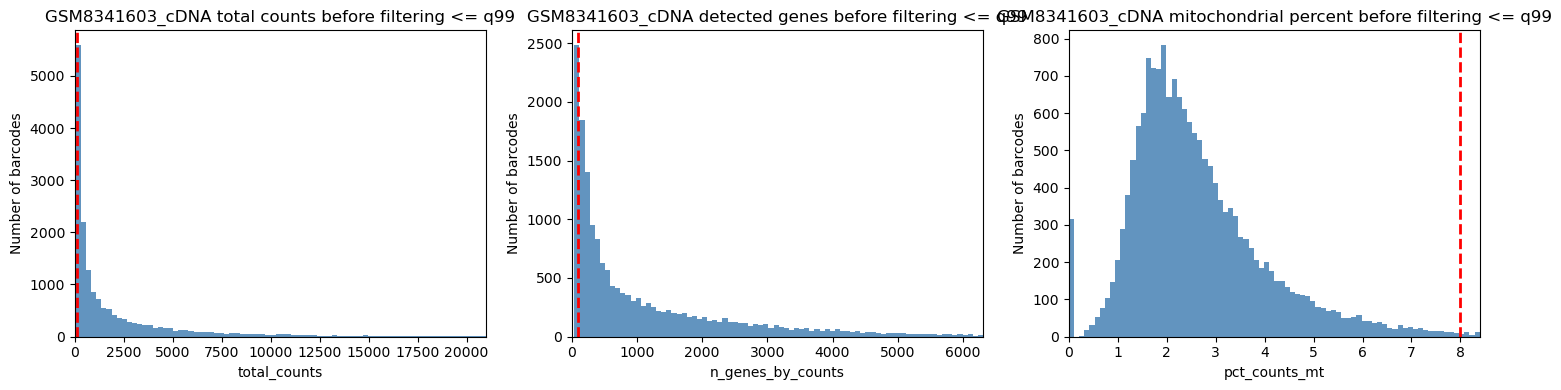

In [10]:
sample_labels = [sample for sample in CDNA_SAMPLES if sample in set(adata.obs['sample_source'].dropna())]
fig, axes = plt.subplots(len(sample_labels), 3, figsize=(15, 4 * len(sample_labels)), squeeze=False)

hist_specs = [
    ('total_counts', 'min_counts', 'total counts', 'total_counts'),
    ('n_genes_by_counts', 'min_genes', 'detected genes', 'n_genes_by_counts'),
    ('pct_counts_mt', 'max_pct_mt', 'mitochondrial percent', 'pct_counts_mt'),
]

for i, sample in enumerate(sample_labels):
    adata_sample = adata[adata.obs['sample_source'] == sample]

    for j, (metric, threshold_key, title_label, xlabel) in enumerate(hist_specs):
        values = adata_sample.obs[metric].dropna()
        threshold = get_qc_threshold(sample, threshold_key)
        x_upper = get_hist_upper(values, metric, threshold)
        plot_values = values[values <= x_upper]

        axes[i, j].hist(plot_values, bins=80, color='steelblue', alpha=0.85)
        axes[i, j].axvline(threshold, color='red', linestyle='--', linewidth=2)
        axes[i, j].set_xlim(left=0, right=x_upper)
        axes[i, j].set_title(f'{sample} {title_label} before filtering <= q{int(qc_plot_upper_quantile[metric] * 100)}')
        axes[i, j].set_xlabel(xlabel)
        axes[i, j].set_ylabel('Number of barcodes')

plt.tight_layout()
plt.savefig(fig_dir / 'cDNA_QC_histograms_by_sample_before_filtering.png', dpi=200, bbox_inches='tight')
plt.show()


,sample,metric,mean,threshold,q01,q05,q10,q25,q50,q75,q90,q95,q99
0,GSM8341603_cDNA,total_counts,2342.621842,100,52.0,70.000000,98.000000,216.000000,686.000000,2568.250000,6353.50000,10200.050000,20985.590000
1,GSM8341603_cDNA,n_genes_by_counts,1170.764935,90,49.0,65.000000,90.900000,191.000000,555.000000,1658.250000,3167.20000,4244.100000,6308.000000
2,GSM8341603_cDNA,pct_counts_mt,2.707142,8,0.0,1.003299,1.278772,1.717847,2.352941,3.306659,4.60053,5.625343,8.385788


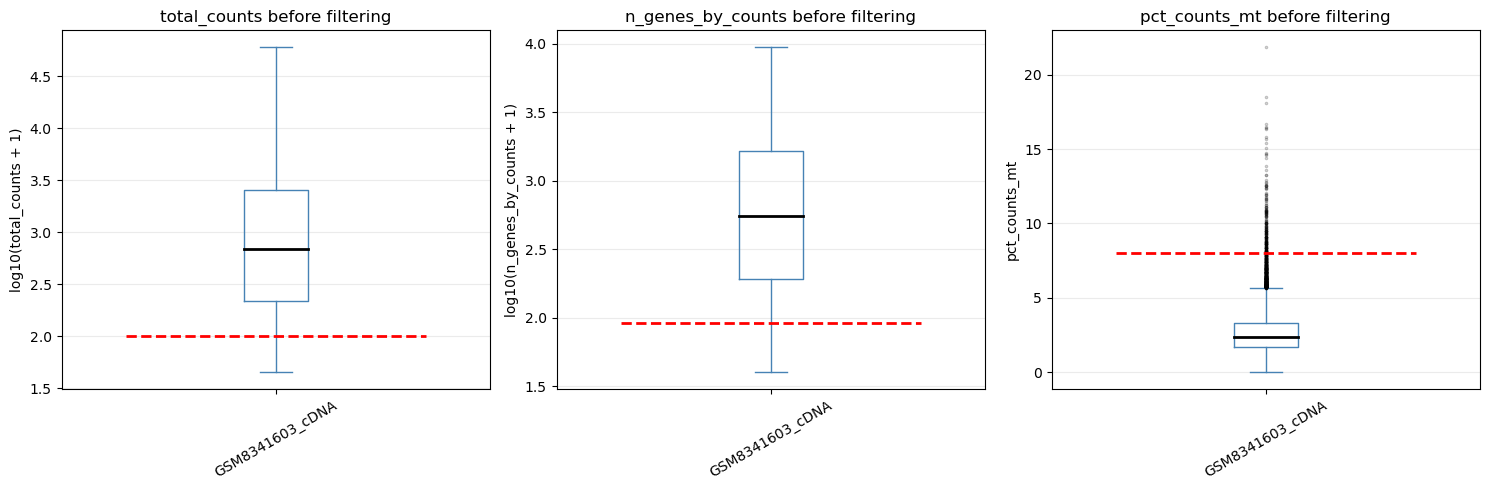

In [11]:
qc_metrics = [
    ('total_counts', 'log10(total_counts + 1)', True, 'min_counts'),
    ('n_genes_by_counts', 'log10(n_genes_by_counts + 1)', True, 'min_genes'),
    ('pct_counts_mt', 'pct_counts_mt', False, 'max_pct_mt'),
]

sample_labels = [sample for sample in CDNA_SAMPLES if sample in set(adata.obs['sample_source'].dropna())]

qc_quantile_rows = []
for sample in sample_labels:
    adata_sample = adata[adata.obs['sample_source'] == sample]
    for metric, _, _, threshold_key in qc_metrics:
        values = adata_sample.obs[metric].dropna()
        quantiles = values.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
        row = {
            'sample': sample,
            'metric': metric,
            'mean': values.mean(),
            'threshold': get_qc_threshold(sample, threshold_key),
        }
        row.update({f'q{int(q * 100):02d}': v for q, v in quantiles.items()})
        qc_quantile_rows.append(row)

qc_quantile_summary = pd.DataFrame(qc_quantile_rows)
qc_quantile_summary.to_csv(CDNA_OUTPUT / 'Adata' / 'cDNA_qc_quantile_summary_by_sample.csv', index=False)
display(qc_quantile_summary)

fig, axes = plt.subplots(1, len(qc_metrics), figsize=(5 * len(qc_metrics), 5), squeeze=False)
axes = axes[0]

for ax, (metric, label, use_log10, threshold_key) in zip(axes, qc_metrics):
    plot_values = []
    threshold_values = []
    for sample in sample_labels:
        values = adata.obs.loc[adata.obs['sample_source'] == sample, metric].dropna()
        threshold = get_qc_threshold(sample, threshold_key)
        if use_log10:
            values = np.log10(values + 1)
            threshold = np.log10(threshold + 1)
        plot_values.append(values)
        threshold_values.append(threshold)

    ax.boxplot(
        plot_values,
        labels=sample_labels,
        showfliers=True,
        flierprops={'marker': '.', 'markersize': 3, 'alpha': 0.25},
        medianprops={'color': 'black', 'linewidth': 2},
        boxprops={'color': 'steelblue'},
        whiskerprops={'color': 'steelblue'},
        capprops={'color': 'steelblue'},
    )

    for x_position, threshold_value in enumerate(threshold_values, start=1):
        ax.hlines(threshold_value, x_position - 0.35, x_position + 0.35, color='red', linestyle='--', linewidth=2)

    ax.set_title(f'{metric} before filtering')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig(fig_dir / 'cDNA_QC_boxplots_by_sample_before_filtering.png', dpi=200, bbox_inches='tight')
plt.show()


In [12]:
qc_summary_rows = []
qc_keep = pd.Series(False, index=adata.obs.index)

for sample in CDNA_SAMPLES:
    sample_mask = adata.obs['sample_source'] == sample
    thresholds = qc_thresholds[sample]
    before = int(sample_mask.sum())
    keep = (
        sample_mask &
        (adata.obs['total_counts'] >= thresholds['min_counts']) &
        (adata.obs['n_genes_by_counts'] >= thresholds['min_genes']) &
        (adata.obs['pct_counts_mt'] <= thresholds['max_pct_mt'])
    )
    qc_keep |= keep
    after = int(keep.sum())
    qc_summary_rows.append({
        'sample': sample,
        'n_barcodes_before': before,
        'n_barcodes_after': after,
        'n_barcodes_removed': before - after,
        'barcode_retention_pct': after / before * 100 if before else 0,
        'min_counts': thresholds['min_counts'],
        'min_genes': thresholds['min_genes'],
        'max_pct_mt': thresholds['max_pct_mt'],
    })

n_genes_before = adata.n_vars
adata = adata[qc_keep].copy()
sc.pp.filter_genes(adata, min_cells=3)
n_genes_after = adata.n_vars

qc_summary = pd.DataFrame(qc_summary_rows)
qc_summary['n_genes_before'] = n_genes_before
qc_summary['n_genes_after'] = n_genes_after
qc_summary['n_genes_removed'] = n_genes_before - n_genes_after
qc_summary['gene_retention_pct'] = n_genes_after / n_genes_before * 100
qc_summary.to_csv(CDNA_OUTPUT / 'Adata' / 'cDNA_qc_filtering_summary_by_sample.csv', index=False)
adata.write_h5ad(CDNA_OUTPUT / 'Adata' / 'adata_qc_filtered.h5ad')
display(qc_summary)


,sample,n_barcodes_before,n_barcodes_after,n_barcodes_removed,barcode_retention_pct,min_counts,min_genes,max_pct_mt,n_genes_before,n_genes_after,n_genes_removed,gene_retention_pct
0,GSM8341603_cDNA,16940,15079,1861,89.014168,100,90,8,26139,21816,4323,83.461494


## QC-filtered cDNA UMAP processing

Run the same normalization, HVG selection, regression, PCA, scaling, neighbors, UMAP, and Leiden workflow on `adata_qc_filtered.h5ad`. Each intermediate AnnData object is saved separately.


Loaded QC-filtered adata: /p2/zulab/jtian/data/IRISeq/demo_processed/output/cDNA/Adata/adata_qc_filtered.h5ad (15079, 21816)


/p1/zulab_users/jtian/anaconda3/envs/my_IRISeq_py38/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


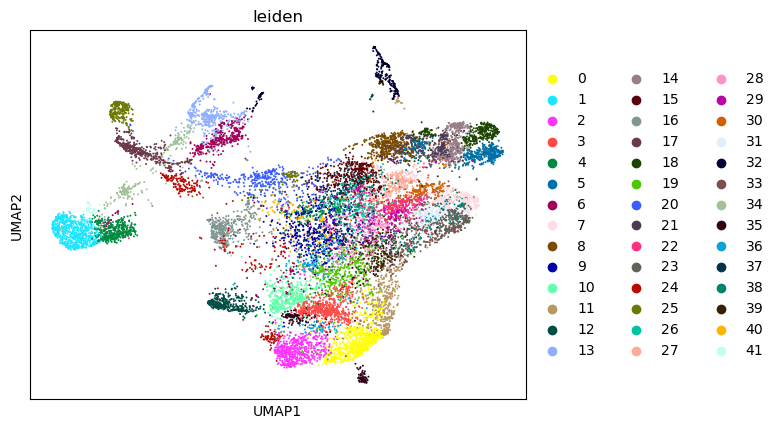

/p1/zulab_users/jtian/anaconda3/envs/my_IRISeq_py38/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


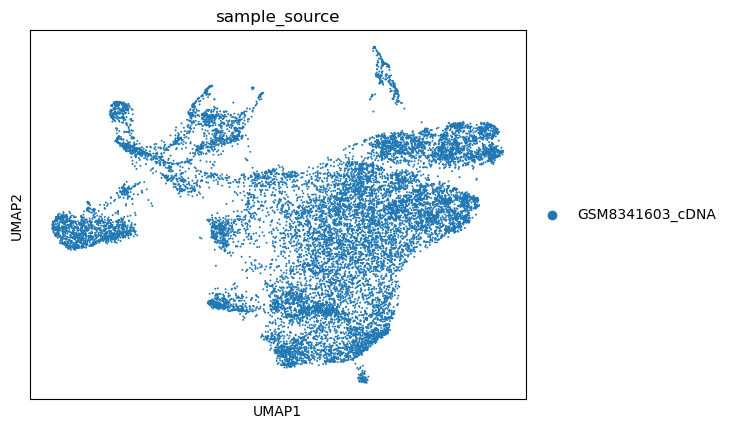

/p1/zulab_users/jtian/anaconda3/envs/my_IRISeq_py38/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


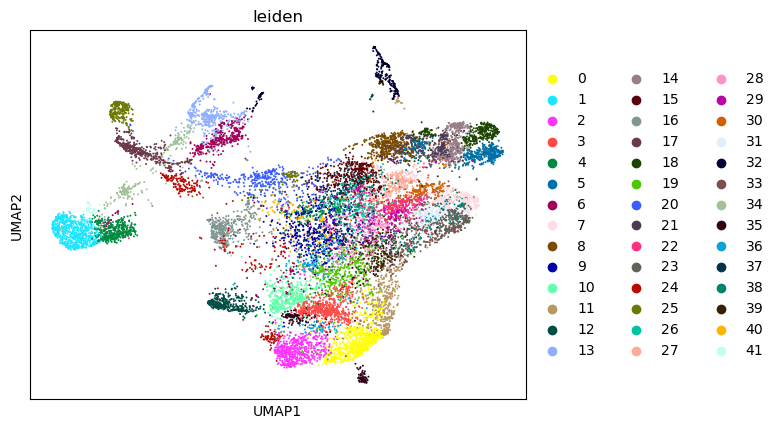

Saved /p2/zulab/jtian/data/IRISeq/demo_processed/output/cDNA/figures/GSM8341603_cDNA_QC_filtered_umap_by_leiden.png
Saved QC-filtered processing AnnData files to /p2/zulab/jtian/data/IRISeq/demo_processed/output/cDNA/Adata


In [13]:
qc_adata_dir = CDNA_OUTPUT / 'Adata'
qc_adata_dir.mkdir(parents=True, exist_ok=True)

qc_filtered_path = qc_adata_dir / 'adata_qc_filtered.h5ad'
assert qc_filtered_path.exists(), f'Missing QC-filtered AnnData file: {qc_filtered_path}'

adata_qc = sc.read_h5ad(qc_filtered_path)
print('Loaded QC-filtered adata:', qc_filtered_path, adata_qc.shape)

# Same processing logic as the original UMAP cell, but applied to QC-filtered cells.
sc.pp.normalize_total(adata_qc, target_sum=1e4)
adata_qc.write_h5ad(qc_adata_dir / 'adata_qc_normalized.h5ad')

sc.pp.log1p(adata_qc)
adata_qc.write_h5ad(qc_adata_dir / 'adata_qc_log1p.h5ad')

sc.pp.highly_variable_genes(adata_qc, min_mean=0.0125, max_mean=5, min_disp=0.5)
adata_qc.write_h5ad(qc_adata_dir / 'adata_qc_hvg_annotated.h5ad')

adata_qc.raw = adata_qc
adata_qc = adata_qc[:, adata_qc.var.highly_variable].copy()
adata_qc.write_h5ad(qc_adata_dir / 'adata_qc_hvg_subset.h5ad')

regressors = [x for x in ['total_counts', 'pct_counts_mt'] if x in adata_qc.obs.columns]
if regressors:
    sc.pp.regress_out(adata_qc, regressors)
adata_qc.write_h5ad(qc_adata_dir / 'adata_qc_regressed.h5ad')

sc.tl.pca(adata_qc)
adata_qc.write_h5ad(qc_adata_dir / 'adata_qc_pca.h5ad')

sc.pp.scale(adata_qc, max_value=10)
adata_qc.write_h5ad(qc_adata_dir / 'adata_qc_scaled.h5ad')

sc.pp.neighbors(adata_qc, n_neighbors=20, n_pcs=25)
adata_qc.write_h5ad(qc_adata_dir / 'adata_qc_neighbors.h5ad')

sc.tl.umap(adata_qc, min_dist=0, spread=3)
adata_qc.write_h5ad(qc_adata_dir / 'adata_qc_umap.h5ad')

sc.tl.leiden(adata_qc, resolution=3)
adata_qc.write_h5ad(qc_adata_dir / 'adata_qc_processed_umap_leiden.h5ad')

fig_dir = CDNA_OUTPUT / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

sc.pl.umap(adata_qc, color=['leiden'], show=False)
fig = plt.gcf()
fig.savefig(fig_dir / 'cDNA_QC_filtered_joint_umap_by_leiden.png', dpi=200, bbox_inches='tight')
plt.show()

sc.pl.umap(adata_qc, color=['sample_source'], show=False)
fig = plt.gcf()
fig.savefig(fig_dir / 'cDNA_QC_filtered_joint_umap_by_sample.png', dpi=200, bbox_inches='tight')
plt.show()

for sample in CDNA_SAMPLES:
    adata_qc_sample = adata_qc[adata_qc.obs['sample_source'] == sample].copy()
    if adata_qc_sample.n_obs == 0:
        print('No QC-filtered cells found for', sample)
        continue
    sc.pl.umap(adata_qc_sample, color=['leiden'], show=False)
    fig = plt.gcf()
    figure_path = fig_dir / f'{sample}_QC_filtered_umap_by_leiden.png'
    fig.savefig(figure_path, dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved', figure_path)

print('Saved QC-filtered processing AnnData files to', qc_adata_dir)


/p1/zulab_users/jtian/anaconda3/envs/my_IRISeq_py38/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


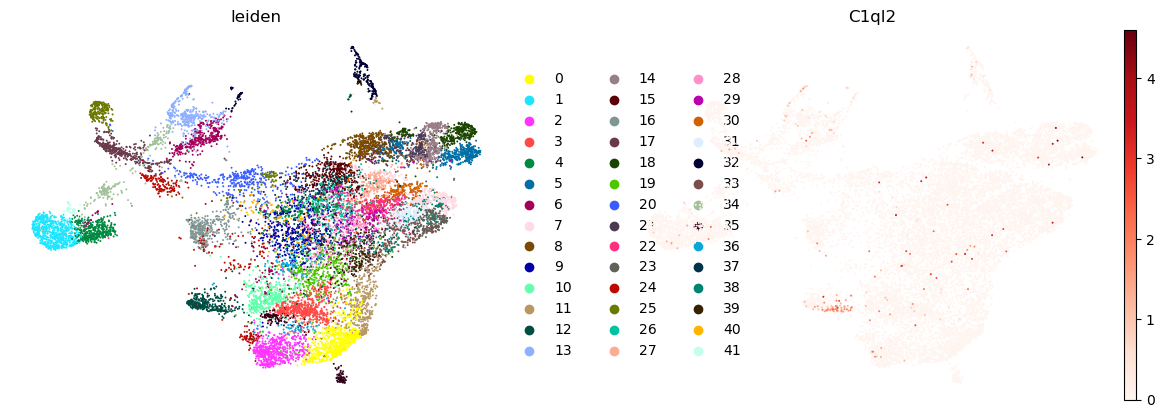

Plotted marker gene: C1ql2 use_raw = True
Saved /p2/zulab/jtian/data/IRISeq/demo_processed/output/cDNA/figures/cDNA_QC_filtered_umap_leiden_C1ql2_expression.png


In [14]:
# Highlight C1ql2 expression on the QC-filtered cDNA Leiden UMAP.
qc_adata_dir = CDNA_OUTPUT / 'Adata'
fig_dir = CDNA_OUTPUT / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

qc_processed_path = qc_adata_dir / 'adata_qc_processed_umap_leiden.h5ad'
assert qc_processed_path.exists(), f'Missing QC-filtered processed AnnData file: {qc_processed_path}'

adata_qc_c1ql2 = sc.read_h5ad(qc_processed_path)

marker_gene = 'C1ql2'
raw_var_names = list(adata_qc_c1ql2.raw.var_names) if adata_qc_c1ql2.raw is not None else []
var_names = list(adata_qc_c1ql2.var_names)
raw_gene_lookup = {gene.upper(): gene for gene in raw_var_names}
var_gene_lookup = {gene.upper(): gene for gene in var_names}

if marker_gene.upper() in raw_gene_lookup:
    marker_gene_to_plot = raw_gene_lookup[marker_gene.upper()]
    use_raw = True
elif marker_gene.upper() in var_gene_lookup:
    marker_gene_to_plot = var_gene_lookup[marker_gene.upper()]
    use_raw = False
else:
    raise ValueError(
        f'{marker_gene} was not found in adata_qc_c1ql2.raw.var_names or adata_qc_c1ql2.var_names.'
    )

sc.pl.umap(
    adata_qc_c1ql2,
    color=['leiden', marker_gene_to_plot],
    use_raw=use_raw,
    cmap='Reds',
    frameon=False,
    show=False,
)
fig = plt.gcf()
figure_path = fig_dir / f'cDNA_QC_filtered_umap_leiden_{marker_gene}_expression.png'
fig.savefig(figure_path, dpi=200, bbox_inches='tight')
plt.show()

print('Plotted marker gene:', marker_gene_to_plot, 'use_raw =', use_raw)
print('Saved', figure_path)


## Spatial interaction matrix and UMAP with 8 nt UMI

This optional section expects the processed bead interaction deduplicated file at `DEDUPLICATE_SPATIAL_UMI8 / f'{sample}.spatial.csv.gz'`. The PCA elbow step now runs before UMAP, and the number of PCs reaching 80% cumulative explained variance is automatically used for UMAP.


Saved /p2/zulab/jtian/data/IRISeq/demo_processed/output/connections/UMAP_UMI8/GSM8341604_interaction_connection_matrix_UMI8.csv shape= (24698, 6997)


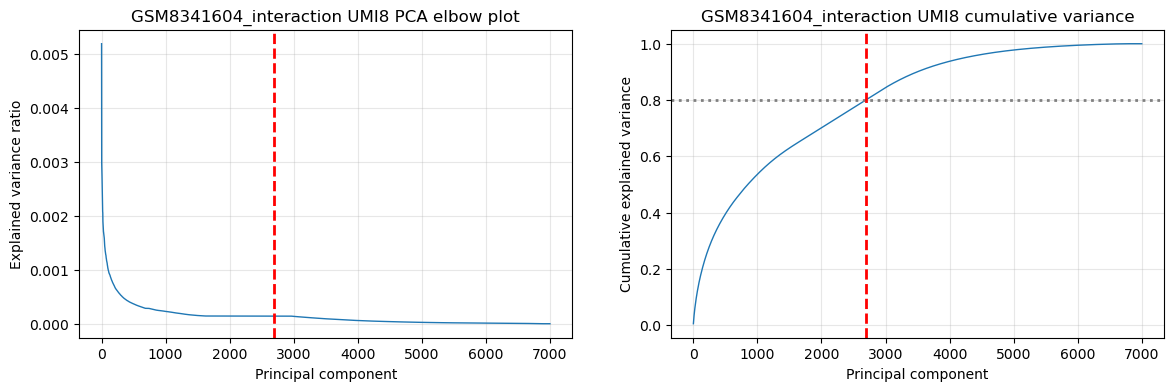

Saved /p2/zulab/jtian/data/IRISeq/demo_processed/output/connections/UMAP_UMI8/PCA_elbow_no_cap/GSM8341604_interaction_connection_UMI8_pca_no_cap_explained_variance.csv
Saved /p2/zulab/jtian/data/IRISeq/demo_processed/output/connections/UMAP_UMI8/PCA_elbow_no_cap/GSM8341604_interaction_connection_UMI8_pca_no_cap_elbow.png
GSM8341604_interaction: selected 2690 PCs for 80% cumulative variance; max PCs tested = 6997


,sample,selected_n_components_for_80pct,max_components_tested
0,GSM8341604_interaction,2690,6997


In [16]:
# Build connection matrices and choose PCA dimensions from the 80% cumulative variance elbow.
UMAP_OUTPUT_UMI8 = CONNECTION_OUTPUT / 'UMAP_UMI8'
PCA_ELBOW_OUTPUT_UMI8 = UMAP_OUTPUT_UMI8 / 'PCA_elbow_no_cap'
UMAP_OUTPUT_UMI8.mkdir(parents=True, exist_ok=True)
PCA_ELBOW_OUTPUT_UMI8.mkdir(parents=True, exist_ok=True)

pca_variance_target_UMI8 = 0.80
connection_matrices_UMI8 = {}
pca_n_components_by_sample_UMI8 = {}
explained_variance_tables_UMI8 = {}

def read_spatial_rmdup(path):
    raw = pd.read_csv(path, compression='gzip', header=None, dtype=str)
    if raw.shape[1] == 1:
        parsed = raw.iloc[:, 0].str.split(',', n=2, expand=True)
    else:
        parsed = raw.iloc[:, :3].copy()
    parsed.columns = ['Bead1_seq', 'UMI', 'Bead2_seq']
    return parsed.dropna(subset=['Bead1_seq', 'UMI', 'Bead2_seq'])

for sample in BEAD_SAMPLES:
    spatial_file = DEDUPLICATE_SPATIAL_UMI8 / f'{sample}.spatial.csv.gz'
    assert spatial_file.exists(), f'Missing processed UMI8 spatial file: {spatial_file}'

    df = read_spatial_rmdup(spatial_file)
    df_grouped = (
        df.groupby(['Bead1_seq', 'Bead2_seq'], observed=True)
          .size()
          .reset_index(name='n_umi')
    )
    df_filter = df_grouped[np.log10(df_grouped['n_umi']) >= 0.8].copy()
    matrix_data_filter = (
        df_filter.pivot(index='Bead1_seq', columns='Bead2_seq', values='n_umi')
                 .fillna(0)
    )

    connection_matrix_csv = UMAP_OUTPUT_UMI8 / f'{sample}_connection_matrix_UMI8.csv'
    matrix_data_filter.to_csv(connection_matrix_csv)
    connection_matrices_UMI8[sample] = matrix_data_filter
    print('Saved', connection_matrix_csv, 'shape=', matrix_data_filter.shape)

    matrix_data_log1p = np.log1p(matrix_data_filter)
    matrix_data_standardized = StandardScaler().fit_transform(matrix_data_log1p)
    n_components_max = min(matrix_data_standardized.shape[0], matrix_data_standardized.shape[1])
    assert n_components_max >= 2, f'Not enough dimensions for PCA in {sample}: shape={matrix_data_standardized.shape}'

    pca = PCA(n_components=n_components_max, svd_solver='randomized', random_state=42)
    pca.fit(matrix_data_standardized)

    explained = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)
    selected_n = int(np.searchsorted(cumulative, pca_variance_target_UMI8) + 1)
    selected_n = min(selected_n, n_components_max)
    pca_n_components_by_sample_UMI8[sample] = selected_n

    variance_df = pd.DataFrame({
        'principal_component': np.arange(1, n_components_max + 1),
        'explained_variance_ratio': explained,
        'cumulative_explained_variance': cumulative,
    })
    explained_variance_tables_UMI8[sample] = variance_df
    variance_csv = PCA_ELBOW_OUTPUT_UMI8 / f'{sample}_connection_UMI8_pca_no_cap_explained_variance.csv'
    variance_df.to_csv(variance_csv, index=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(variance_df['principal_component'], variance_df['explained_variance_ratio'], linewidth=1)
    axes[0].axvline(selected_n, color='red', linestyle='--', linewidth=2)
    axes[0].set_title(f'{sample} UMI8 PCA elbow plot')
    axes[0].set_xlabel('Principal component')
    axes[0].set_ylabel('Explained variance ratio')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(variance_df['principal_component'], variance_df['cumulative_explained_variance'], linewidth=1)
    axes[1].axhline(pca_variance_target_UMI8, color='gray', linestyle=':', linewidth=2)
    axes[1].axvline(selected_n, color='red', linestyle='--', linewidth=2)
    axes[1].set_title(f'{sample} UMI8 cumulative variance')
    axes[1].set_xlabel('Principal component')
    axes[1].set_ylabel('Cumulative explained variance')
    axes[1].grid(True, alpha=0.3)

    figure_path = PCA_ELBOW_OUTPUT_UMI8 / f'{sample}_connection_UMI8_pca_no_cap_elbow.png'
    fig.savefig(figure_path, dpi=200, bbox_inches='tight')
    plt.show()

    print('Saved', variance_csv)
    print('Saved', figure_path)
    print(f'{sample}: selected {selected_n} PCs for {pca_variance_target_UMI8:.0%} cumulative variance; max PCs tested = {n_components_max}')

pca_selection_summary_UMI8 = pd.DataFrame([
    {
        'sample': sample,
        'selected_n_components_for_80pct': n_components,
        'max_components_tested': min(connection_matrices_UMI8[sample].shape),
    }
    for sample, n_components in pca_n_components_by_sample_UMI8.items()
])
pca_selection_summary_UMI8.to_csv(PCA_ELBOW_OUTPUT_UMI8 / 'UMI8_pca_selected_components.csv', index=False)
display(pca_selection_summary_UMI8)


/p1/zulab_users/jtian/anaconda3/envs/my_IRISeq_py38/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP(min_dist=0.2, n_epochs=500, n_jobs=1, n_neighbors=25, random_state=42, spread=0.6, verbose=True)
Mon Jun  1 12:32:43 2026 Construct fuzzy simplicial set
Mon Jun  1 12:32:43 2026 Finding Nearest Neighbors
Mon Jun  1 12:32:43 2026 Building RP forest with 13 trees
Mon Jun  1 12:33:22 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	 5  /  15
	 6  /  15
	Stopping threshold met -- exiting after 6 iterations
Mon Jun  1 12:36:55 2026 Finished Nearest Neighbor Search
Mon Jun  1 12:36:56 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon Jun  1 12:37:35 2026 Finished embedding


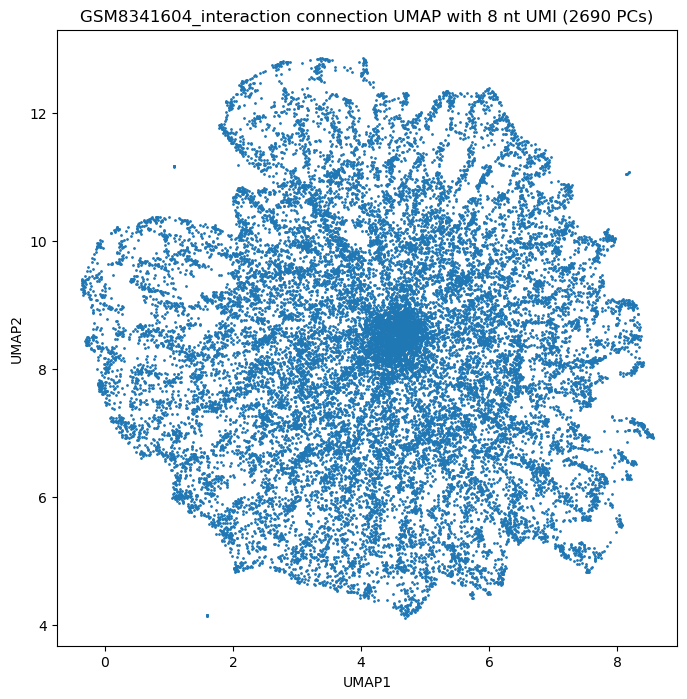

Used 2690 PCs selected from 80% cumulative explained variance
Saved /p2/zulab/jtian/data/IRISeq/demo_processed/output/connections/UMAP_UMI8/GSM8341604_interaction_connection_umap_UMI8.csv
Saved /p2/zulab/jtian/data/IRISeq/demo_processed/output/connections/UMAP_UMI8/GSM8341604_interaction_connection_umap_UMI8.png


In [17]:
# Run UMAP using the 80%-variance PC count selected by the elbow/cumulative-variance cell above.
UMAP_OUTPUT_UMI8 = CONNECTION_OUTPUT / 'UMAP_UMI8'
PCA_ELBOW_OUTPUT_UMI8 = UMAP_OUTPUT_UMI8 / 'PCA_elbow_no_cap'
connection_umaps_UMI8 = {}

if 'pca_n_components_by_sample_UMI8' not in globals():
    selection_csv = PCA_ELBOW_OUTPUT_UMI8 / 'UMI8_pca_selected_components.csv'
    assert selection_csv.exists(), f'Missing PCA selection summary: {selection_csv}'
    selection_df = pd.read_csv(selection_csv)
    pca_n_components_by_sample_UMI8 = dict(zip(selection_df['sample'], selection_df['selected_n_components_for_80pct']))

for sample in BEAD_SAMPLES:
    matrix_path = UMAP_OUTPUT_UMI8 / f'{sample}_connection_matrix_UMI8.csv'
    assert matrix_path.exists(), f'Missing UMI8 connection matrix: {matrix_path}'
    assert sample in pca_n_components_by_sample_UMI8, f'Missing selected PCA component count for {sample}'

    matrix_data_filter = pd.read_csv(matrix_path, index_col=0)
    matrix_data_log1p = np.log1p(matrix_data_filter)
    matrix_data_standardized = StandardScaler().fit_transform(matrix_data_log1p)
    n_components = int(pca_n_components_by_sample_UMI8[sample])
    n_components = min(n_components, min(matrix_data_standardized.shape))

    matrix_data_pca = PCA(n_components=n_components, svd_solver='randomized', random_state=42).fit_transform(matrix_data_standardized)
    coords = umap.UMAP(
        n_neighbors=25,
        min_dist=0.2,
        metric='euclidean',
        random_state=42,
        n_epochs=500,
        verbose=True,
        spread=0.6,
    ).fit_transform(matrix_data_pca)

    umap_df = pd.DataFrame(coords, columns=['UMAP1', 'UMAP2'], index=matrix_data_filter.index)
    umap_df.index.name = 'connection_barcode'
    connection_umap_csv = UMAP_OUTPUT_UMI8 / f'{sample}_connection_umap_UMI8.csv'
    umap_df.to_csv(connection_umap_csv)
    connection_umaps_UMI8[sample] = umap_df

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(coords[:, 0], coords[:, 1], s=1)
    ax.set_aspect('equal', 'datalim')
    ax.set_title(f'{sample} connection UMAP with 8 nt UMI ({n_components} PCs)')
    ax.set_xlabel('UMAP1')
    ax.set_ylabel('UMAP2')
    figure_path = UMAP_OUTPUT_UMI8 / f'{sample}_connection_umap_UMI8.png'
    fig.savefig(figure_path, dpi=200, bbox_inches='tight')
    plt.show()
    print('Used', n_components, 'PCs selected from 80% cumulative explained variance')
    print('Saved', connection_umap_csv)
    print('Saved', figure_path)


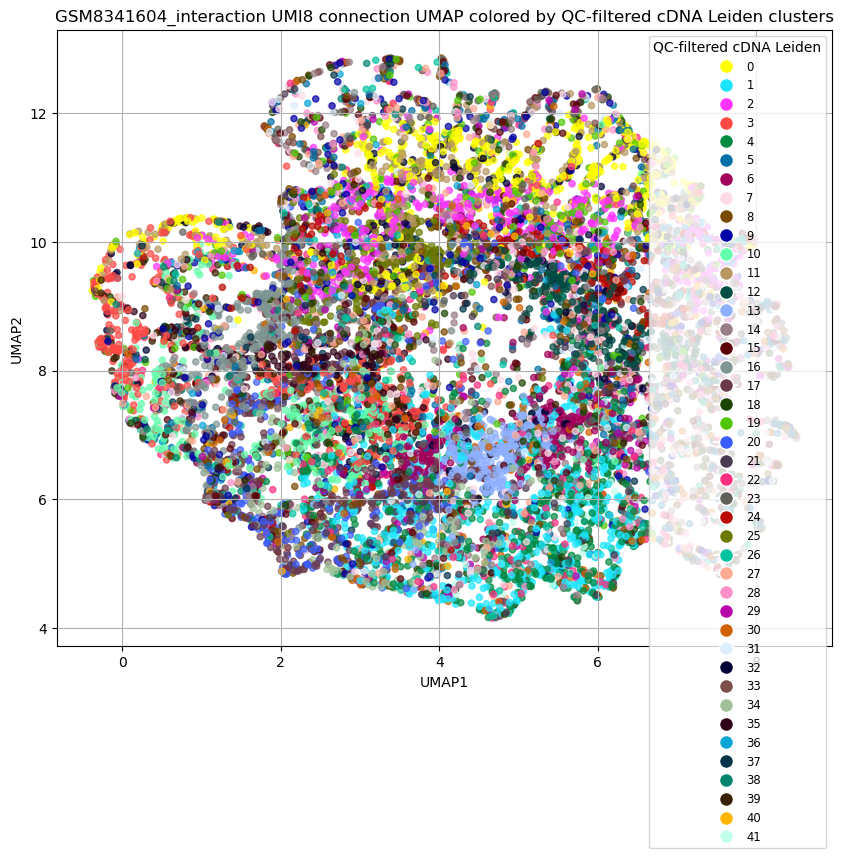

Saved /p2/zulab/jtian/data/IRISeq/demo_processed/output/connections/UMAP_UMI8/QC_filtered_cDNA_merge/GSM8341604_interaction_connection_umap_UMI8_by_QC_filtered_cDNA_leiden.png matched unique QC-filtered cells= 14597


,bead_sample,connection_umap_source,cDNA_leiden_cluster,n_qc_filtered_cDNA_cells,n_cells_matched_to_UMI8_beads,matched_pct
0,GSM8341604_interaction,/p2/zulab/jtian/data/IRISeq/demo_processed/out...,0,742,730,98.382749
1,GSM8341604_interaction,/p2/zulab/jtian/data/IRISeq/demo_processed/out...,1,695,687,98.848921
2,GSM8341604_interaction,/p2/zulab/jtian/data/IRISeq/demo_processed/out...,2,625,620,99.200000
3,GSM8341604_interaction,/p2/zulab/jtian/data/IRISeq/demo_processed/out...,3,575,554,96.347826
4,GSM8341604_interaction,/p2/zulab/jtian/data/IRISeq/demo_processed/out...,4,574,562,97.909408
5,GSM8341604_interaction,/p2/zulab/jtian/data/IRISeq/demo_processed/out...,5,457,406,88.840263
6,GSM8341604_interaction,/p2/zulab/jtian/data/IRISeq/demo_processed/out...,6,437,433,99.084668
7,GSM8341604_interaction,/p2/zulab/jtian/data/IRISeq/demo_processed/out...,7,434,399,91.935484
8,GSM8341604_interaction,/p2/zulab/jtian/data/IRISeq/demo_processed/out...,8,434,415,95.622120
9,GSM8341604_interaction,/p2/zulab/jtian/data/IRISeq/demo_processed/out...,9,432,427,98.842593


Saved /p2/zulab/jtian/data/IRISeq/demo_processed/output/connections/UMAP_UMI8/QC_filtered_cDNA_merge/QC_filtered_cDNA_cluster_UMI8_bead_match_counts.csv


In [20]:
# Re-run the QC-filtered cDNA cluster overlay using the UMI8 bead connection UMAPs.
# Inputs are the UMI8 UMAP CSVs generated by the section above; outputs go to a new folder.
UMAP_OUTPUT_UMI8 = CONNECTION_OUTPUT / 'UMAP_UMI8'
QC_MERGE_OUTPUT_UMI8 = UMAP_OUTPUT_UMI8 / 'QC_filtered_cDNA_merge'
QC_MERGE_OUTPUT_UMI8.mkdir(parents=True, exist_ok=True)

qc_processed_path = CDNA_OUTPUT / 'Adata' / 'adata_qc_processed_umap_leiden.h5ad'
assert qc_processed_path.exists(), f'Missing QC-filtered processed AnnData file: {qc_processed_path}'

adata_qc_merge_UMI8 = sc.read_h5ad(qc_processed_path)
assert 'leiden' in adata_qc_merge_UMI8.obs.columns, 'Missing leiden clusters in QC-filtered processed AnnData.'
assert 'extracted_ID' in adata_qc_merge_UMI8.obs.columns, 'Missing extracted_ID in QC-filtered processed AnnData.'

if hasattr(adata_qc_merge_UMI8.obs['leiden'], 'cat'):
    labels_UMI8 = list(adata_qc_merge_UMI8.obs['leiden'].cat.categories)
else:
    labels_UMI8 = sorted(adata_qc_merge_UMI8.obs['leiden'].dropna().astype(str).unique())
    adata_qc_merge_UMI8.obs['leiden'] = pd.Categorical(
        adata_qc_merge_UMI8.obs['leiden'].astype(str),
        categories=labels_UMI8,
    )

colors_UMI8 = sc.pl.palettes.default_102
cluster_colors_UMI8 = {cluster: colors_UMI8[i % len(colors_UMI8)] for i, cluster in enumerate(labels_UMI8)}
handles_UMI8 = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cluster_colors_UMI8[cat], markersize=10)
    for cat in labels_UMI8
]

cluster_match_summary_rows_UMI8 = []
matched_obs_by_sample_UMI8 = {}
plot_obs_UMI8 = adata_qc_merge_UMI8.obs.copy()
plot_obs_UMI8['cell_name_temp'] = plot_obs_UMI8.index

total_by_cluster_UMI8 = plot_obs_UMI8.groupby('leiden', observed=False).size().reindex(labels_UMI8, fill_value=0)

for sample in BEAD_SAMPLES:
    connection_umap_csv = UMAP_OUTPUT_UMI8 / f'{sample}_connection_umap_UMI8.csv'
    assert connection_umap_csv.exists(), f'Missing UMI8 connection UMAP file: {connection_umap_csv}'

    df = pd.read_csv(connection_umap_csv)
    connection_key_candidates = ['connection_barcode', 'Bead1_seq', 'Unnamed: 0']
    connection_key = next((col for col in connection_key_candidates if col in df.columns), None)
    assert connection_key is not None, f'No connection barcode column found in {connection_umap_csv}; columns={list(df.columns)}'
    assert {'UMAP1', 'UMAP2'}.issubset(df.columns), f'Missing UMAP columns in {connection_umap_csv}; columns={list(df.columns)}'

    connection_coords = (
        df[[connection_key, 'UMAP1', 'UMAP2']]
        .rename(columns={'UMAP1': 'connection_UMAP1', 'UMAP2': 'connection_UMAP2'})
    )
    merged = plot_obs_UMI8.merge(
        connection_coords,
        left_on='extracted_ID',
        right_on=connection_key,
        how='left',
    )
    merged.index = merged['cell_name_temp']
    merged = merged.drop(columns=[connection_key], errors='ignore')
    matched = merged.dropna(subset=['connection_UMAP1', 'connection_UMAP2']).copy()
    matched['UMAP1'] = matched['connection_UMAP1']
    matched['UMAP2'] = matched['connection_UMAP2']

    matched_unique = matched.drop_duplicates(subset=['cell_name_temp']).copy()
    matched_obs_by_sample_UMI8[sample] = matched_unique
    matched_by_cluster = matched_unique.groupby('leiden', observed=False).size().reindex(labels_UMI8, fill_value=0)

    for cluster in labels_UMI8:
        total_cells = int(total_by_cluster_UMI8.loc[cluster])
        matched_cells = int(matched_by_cluster.loc[cluster])
        cluster_match_summary_rows_UMI8.append({
            'bead_sample': sample,
            'connection_umap_source': str(connection_umap_csv),
            'cDNA_leiden_cluster': cluster,
            'n_qc_filtered_cDNA_cells': total_cells,
            'n_cells_matched_to_UMI8_beads': matched_cells,
            'matched_pct': matched_cells / total_cells * 100 if total_cells else 0,
        })

    colors_mapped = matched_unique['leiden'].map(cluster_colors_UMI8).tolist()
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(matched_unique['UMAP1'], matched_unique['UMAP2'], c=colors_mapped, s=20, alpha=0.7)
    ax.legend(handles=handles_UMI8, labels=labels_UMI8, loc='upper right', fontsize='small', title='QC-filtered cDNA Leiden')
    ax.set_title(f'{sample} UMI8 connection UMAP colored by QC-filtered cDNA Leiden clusters')
    ax.set_xlabel('UMAP1')
    ax.set_ylabel('UMAP2')
    ax.grid(True)
    figure_path = QC_MERGE_OUTPUT_UMI8 / f'{sample}_connection_umap_UMI8_by_QC_filtered_cDNA_leiden.png'
    fig.savefig(figure_path, dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved', figure_path, 'matched unique QC-filtered cells=', matched_unique.shape[0])

cluster_match_summary_UMI8 = pd.DataFrame(cluster_match_summary_rows_UMI8)
cluster_match_summary_path_UMI8 = QC_MERGE_OUTPUT_UMI8 / 'QC_filtered_cDNA_cluster_UMI8_bead_match_counts.csv'
cluster_match_summary_UMI8.to_csv(cluster_match_summary_path_UMI8, index=False)
display(cluster_match_summary_UMI8)
print('Saved', cluster_match_summary_path_UMI8)
